# Introduction

This project was carried out as part of my data science internship program, where I was tasked with demonstrating core data science competencies across the complete analytical workflow. The project covers 
- data collection and understanding,
- data cleaning and preprocessing,
- exploratory data analysis (EDA),
- data visualization, and
- predictive modeling using a student performance dataset.

The objective of the analysis is to explore the factors influencing student academic performance and develop a machine learning model capable of predicting student outcomes based on the available features.

---

I start by importing the libraries necessary for loading and plotting the dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
%matplotlib inline

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/mikedammy/data-science-portfolio/\
refs/heads/main/intern-projects/student_performance_data.csv')

In [5]:
df.head(5)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB
None


## Dataset Features Description

The dataset contains demographic, academic, and extracurricular information about students, alongside their academic performance indicators. Below is a description of each feature used in the analysis:

- `StudentID`: Unique identifier assigned to each student. Values range from 1001 to 3392.
- `Age`: Represents the age of the student, ranging from 15 to 18 years.
- `Gender`: Indicates the gender of the student where:
        0 = Male
        1 = Female
- `Ethnicity`: Represents the ethnic background of the student where:
        0 = Caucasian
        1 = African American
        2 = Asian
        3 = Other
- `ParentalEducation`: Describes the highest educational level attained by the student's parents where:
        0 = None
        1 = High School
        2 = Some College
        3 = Bachelor's Degree
        4 = Higher Education
- `StudyTimeWeekly`: Total amount of study time per week measured in hours. Values range from 0 to 20 hours.
- `Absences`: Number of school absences recorded for each student. Values range from 0 to 30.
- `Tutoring`: Indicates whether the student receives tutoring support where:
        0 = No
        1 = Yes
- `ParentalSupport`: Measures the level of parental support available to the student where:
        0 = None
        1 = Low
        2 = Moderate
        3 = High
        4 = Very High
- `Extracurricular`: Indicates participation in extracurricular activities where:
        0 = No
        1 = Yes
- `Sports`: Indicates whether the student participates in sports activities where:
        0 = No
        1 = Yes
- `Music`: Indicates participation in music-related activities where:
        0 = No
        1 = Yes
- `Volunteering`: Indicates whether the student participates in volunteering activities where:
        0 = No
        1 = Yes
- `GPA`: Represents the student's Grade Point Average on a scale from 0.0 to 4.0.
- `GradeClass`: Represents the student's academic grade classification based on GPA where:
        0 = A (GPA ≥ 3.5)
        1 = B (GPA between 3.0 and 3.49)
        2 = C (GPA between 2.5 and 2.99)
        3 = D (GPA between 2.0 and 2.49)
        4 = F (GPA < 2.0)

In [7]:
print(f"Number of NANs: {df.isna().any().sum()}")
print(f"Number of duplicates: {df.duplicated().sum()}")

Number of NANs: 0
Number of duplicates: 0


## Exploratory Data Analysis (EDA) and Visualization

In this section I perform exploratory data analysis by presenting the descriptive statistics and correlation analysis in the dataset.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,2392.0,2196.500000,690.655244,1001.000000,1598.750000,2196.500000,2794.250000,3392.000000
Age,2392.0,16.468645,1.123798,15.000000,15.000000,16.000000,17.000000,18.000000
Gender,2392.0,0.510870,0.499986,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2392.0,0.877508,1.028476,0.000000,0.000000,0.000000,2.000000,3.000000
ParentalEducation,2392.0,1.746237,1.000411,0.000000,1.000000,2.000000,2.000000,4.000000
StudyTimeWeekly,2392.0,9.771992,5.652774,0.001057,5.043079,9.705363,14.408410,19.978094
Absences,2392.0,14.541388,8.467417,0.000000,7.000000,15.000000,22.000000,29.000000
Tutoring,2392.0,0.301421,0.458971,0.000000,0.000000,0.000000,1.000000,1.000000
ParentalSupport,2392.0,2.122074,1.122813,0.000000,1.000000,2.000000,3.000000,4.000000
Extracurricular,2392.0,0.383361,0.486307,0.000000,0.000000,0.000000,1.000000,1.000000


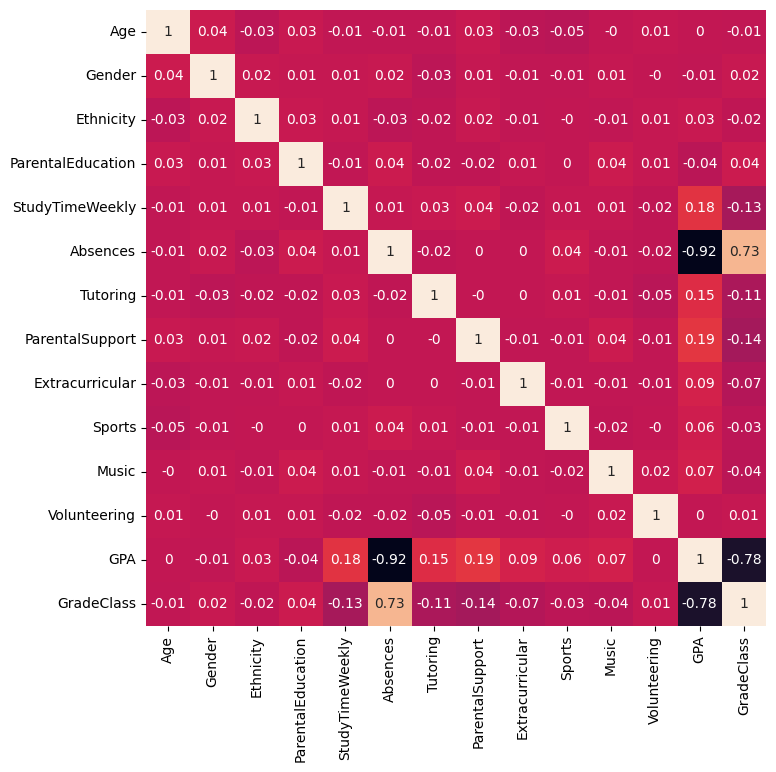

In [9]:
corr_df = round(df.drop(columns='StudentID').corr(), 2)

plt.figure(figsize=(8, 8))
sns.heatmap(
    data=corr_df,
    annot=True,
    cbar=False
)

plt.show()

In the above descriptive statistics, there appear to be no outlier in the dataset and nearly all of the columns are on a similar scale. The `Age`, `Absences` and `StudyTimeWeekly` will be scaled later on to ensure accurate regression results.

The correlation heatmap shows no significant correlation among any of the variables, except for the high absolute value of 0.92 between `Absences` and `GPA`. This gives us insight into what could be one of the most influential factors affecting student performance.

---

In the next section I transform the columns' values into labels to assist in data visualization, and then visualize the data to analyze trends in it.

In [10]:
def map_data(data: pd.DataFrame) -> pd.DataFrame:

    data = data.copy()

    binary_cols = [
        "Tutoring", 'Extracurricular', 'Sports',
        'Music', 'Volunteering'
    ]

    ethnicity_map = {
        0: 'Caucasian',
        1: 'African American',
        2: 'Asian',
        3: 'Other'
    }

    parent_map = {
        0: 'None',
        1: 'High School',
        2: 'Some College',
        3: "Bachelors",
        4: 'Higher'
    }

    support_map = {
        0: 'None',
        1: 'Low',
        2: 'Moderate',
        3: 'High',
        4: 'Very High'
    }

    class_map = {
        0: 'A',
        1: 'B',
        2: 'C',
        3: 'D',
        4: 'F'
    }

    data['Gender'] = data['Gender'].apply(
        lambda x: 'Female' if x==1 else 'Male'
    )

    data['Ethnicity'] = data['Ethnicity'].replace(ethnicity_map)
    data['ParentalEducation'] = data['ParentalEducation'].replace(
        parent_map
    )
    data['ParentalSupport'] = data['ParentalSupport'].replace(support_map)
    data['GradeClass'] = data['GradeClass'].replace(class_map)

    for each in binary_cols:
        data[each] = data[each].apply(
            lambda x: 'Yes' if x==int(1) else 'No'
        )

    return data
    

In [11]:
df_new = map_data(df)
df_new = df_new.set_index("StudentID")
df_new.head(10)

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
StudentID,,,,,,,,,,,,,,
1001,17,Female,Caucasian,Some College,19.833723,7,Yes,Moderate,No,No,Yes,No,2.929196,C
1002,18,Male,Caucasian,High School,15.408756,0,No,Low,No,No,No,No,3.042915,B
1003,15,Male,Asian,Bachelors,4.210570,26,No,Moderate,No,No,No,No,0.112602,F
1004,17,Female,Caucasian,Bachelors,10.028829,14,No,High,Yes,No,No,No,2.054218,D
1005,17,Female,Caucasian,Some College,4.672495,17,Yes,High,No,No,No,No,1.288061,F
1006,18,Male,Caucasian,High School,8.191219,0,No,Low,Yes,No,No,No,3.084184,B
1007,15,Male,African American,High School,15.601680,10,No,High,No,Yes,No,No,2.748237,C
1008,15,Female,African American,Higher,15.424496,22,Yes,Low,Yes,No,No,No,1.360143,F
1009,17,Male,Caucasian,None,4.562008,1,No,Moderate,No,Yes,No,Yes,2.896819,C


One thing I noticed after labelling the data was that some students were given wrong grade classes based on their GPA. So I engineered a new column to compare the given grade class vs the expected grade class.

In [12]:
df_new['MyClass'] = pd.cut(
    df_new['GPA'],
    bins=[0., 2, 2.5, 3, 3.5, np.inf],
    labels=['F', 'D', 'C', 'B', 'A'],
    right=False,
    ordered=True
)

In [13]:
df_new.loc[
    (df_new['GradeClass'] != (df_new['MyClass']))
]

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,MyClass
StudentID,,,,,,,,,,,,,,,
3177,18,Female,Caucasian,Some College,17.528419,3,No,High,No,No,Yes,No,3.137624,D,B
3178,18,Male,Asian,High School,4.033104,3,Yes,High,No,No,No,Yes,3.189217,C,B
3179,17,Female,African American,Higher,1.564842,14,No,Low,No,Yes,No,No,1.795369,D,F
3180,18,Female,African American,Some College,15.762379,14,No,Moderate,Yes,Yes,No,No,2.435958,F,D
3182,15,Male,Asian,High School,3.253044,13,Yes,Low,No,No,No,No,1.844056,B,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3388,18,Female,Caucasian,Bachelors,10.680555,2,No,Very High,Yes,No,No,No,3.455509,A,B
3389,17,Male,Caucasian,High School,7.583217,4,Yes,Very High,No,Yes,No,No,3.279150,F,B
3390,16,Female,Caucasian,Some College,6.805500,20,No,Moderate,No,No,No,Yes,1.142333,C,F


As can be seen from the above dataframe, 168 students were given wrong grade classes, some were given more than they deserved, while others were given less than they deserved.

While the `GradeClass` column will not be used in further analysis, it is worth noting the erroe in the data.

In [14]:
""" Function for plotting the bar charts """

def plot_bar(
    column: str, hue: str = 'Gender',
    data: pd.DataFrame = df_new, orient: str = 'v'
):
    data = data.copy()

    if column not in data.columns:
        return f"Error! Column {column} is not in the dataframe."

    if column == hue:
        return "Column and hue cannot be the same"

    plt.figure(figsize=(8,6))
    if not hue:
        group = (
        data.groupby([column], observed=False)['GPA']
        .mean().reset_index()
        )
        hue = None
        order = None
        
    else:
        group = (
            data.groupby([column, hue], observed=False)['GPA']
            .mean().reset_index()
        )

        order = (
            group.groupby(column)['GPA']
            .mean().sort_values().index
        )

        sns.stripplot(
            data=group,
            x=column, y='GPA', hue=hue,
            dodge=True, marker='o', size=7,
            palette='dark:white', edgecolor='red', linewidth=1.5,
            legend=False, order=order
        )

    if orient == 'v':
        sns.barplot(
            data=group,
            x=column, y='GPA', hue=hue,
            order=order, orient=orient
        )
        plt.title(f"Average GPA by {column}")
        plt.ylabel('Average GPA')
        plt.tight_layout()
        plt.show()

    elif orient == 'h':
        sns.barplot(
        data=group,
        y=column, x='GPA', hue=hue,
        order=order, orient=orient
        )
        plt.title(f"Average GPA by {column}")
        plt.xlabel('Average GPA')
        plt.tight_layout()
        plt.show()
    else:
        return 'Invalid orient value'

    


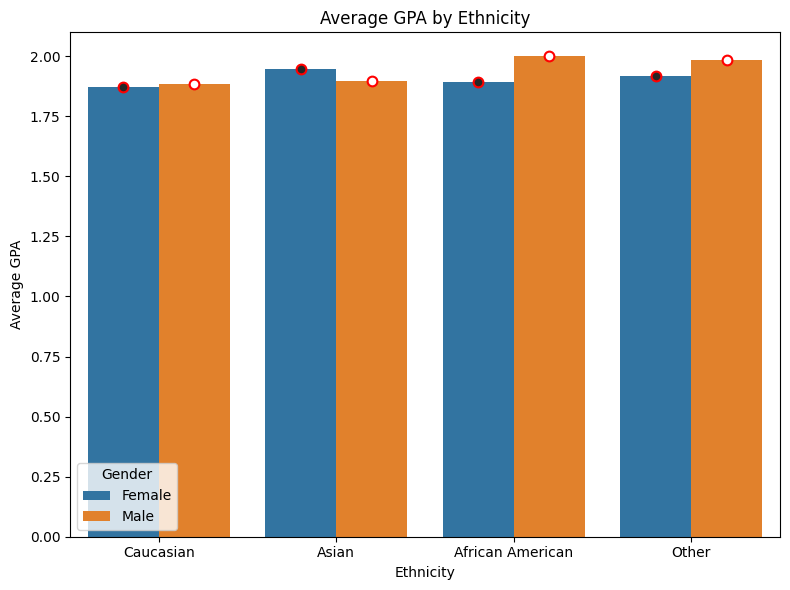

In [15]:
plot_bar('Ethnicity')

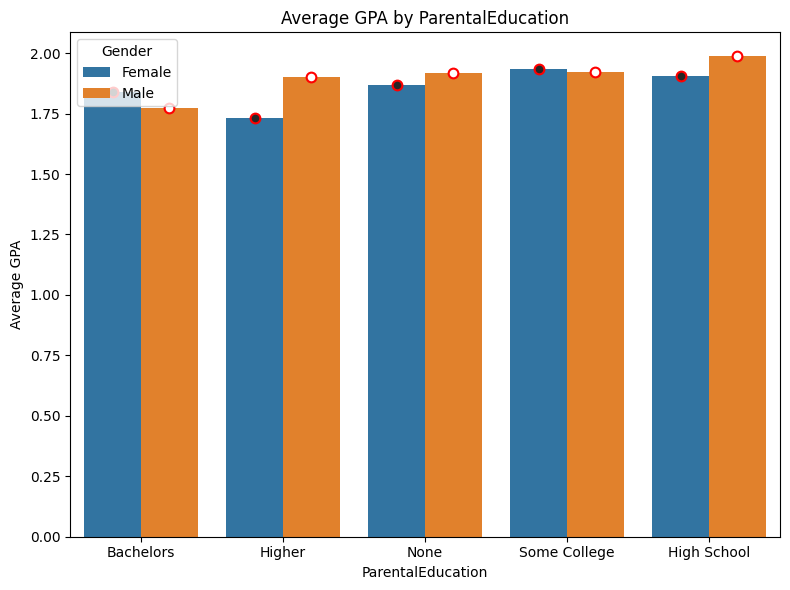

In [16]:
plot_bar('ParentalEducation')

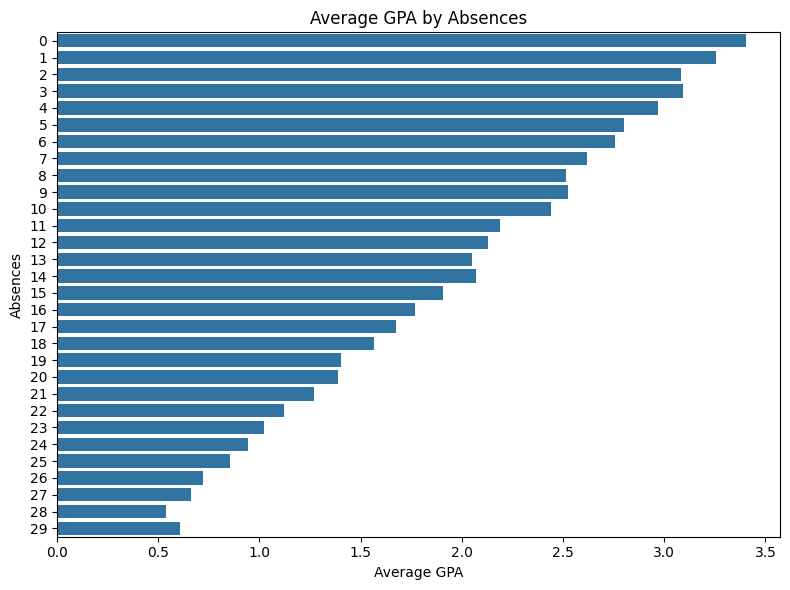

In [21]:
plot_bar('Absences', orient='h', hue=False)

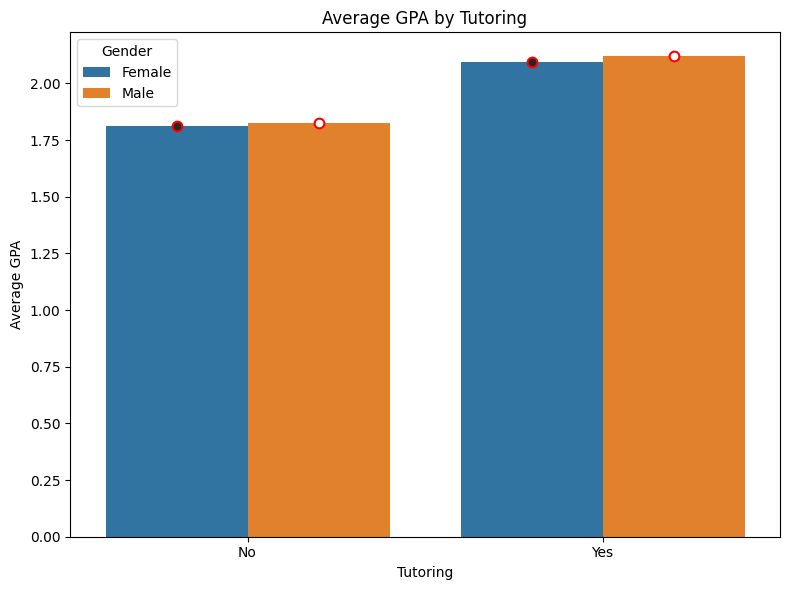

In [18]:
plot_bar('Tutoring')

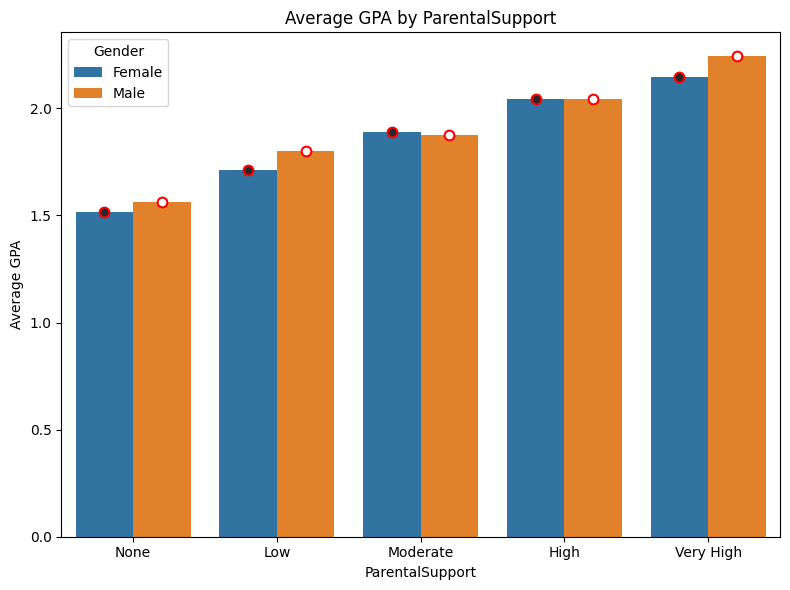

In [19]:
plot_bar('ParentalSupport')

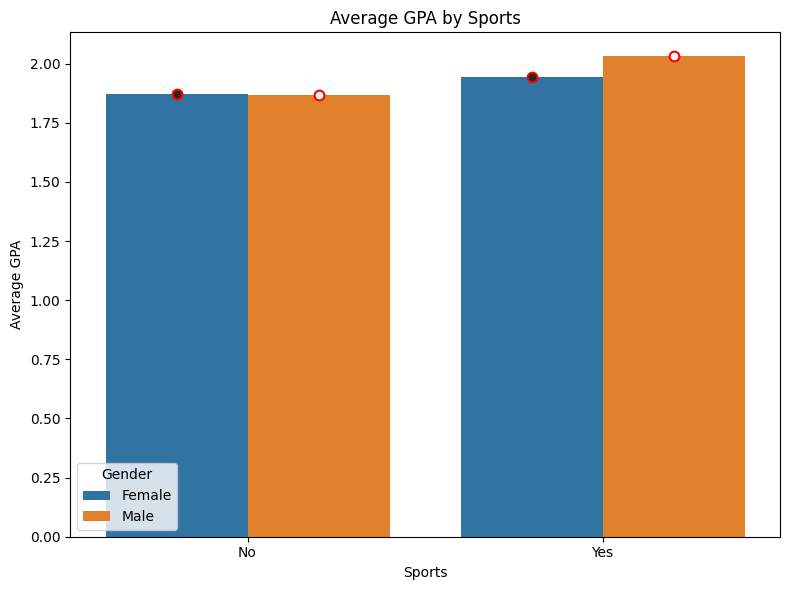

In [22]:
plot_bar('Sports')

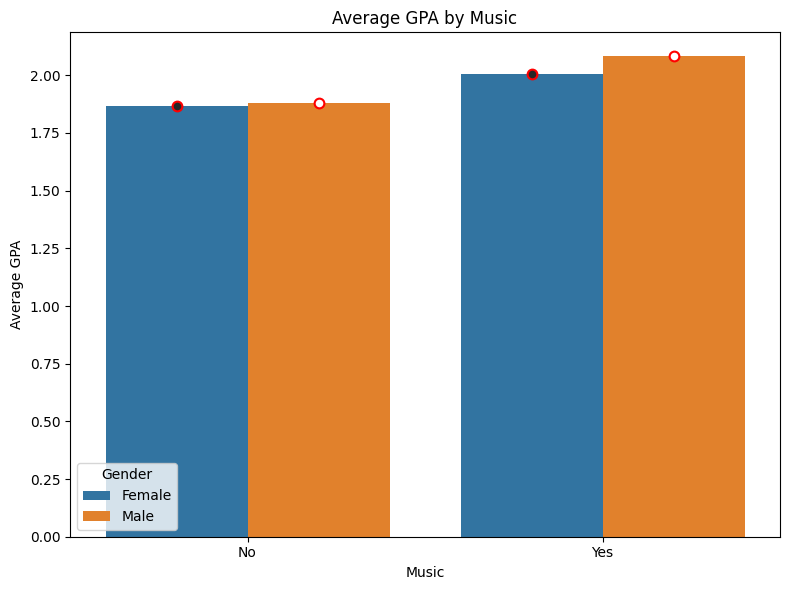

In [23]:
plot_bar('Music')

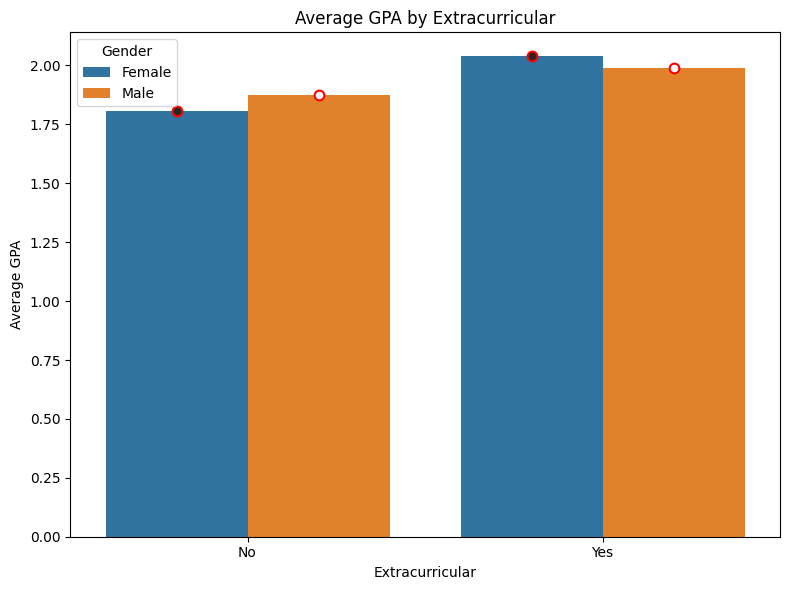

In [24]:
plot_bar('Extracurricular')

**Interpretation**

A couple of relationships can be seen from the above plotted charts: Sports, Ethnicity, and Gender have no significant relationship with GPA as average GPA among their different classes of was not overly different from each other.

On the other hand, Tutoring, ParentalSupport, Extracurricular and Absences have varying relationships with GPA. As ParentalSupport increased from "None" to "Very High", average GPA also increased. Student who received Tutoring, participated in Extracurricular activities, and Music performed slightly better on average than those who didn't.

There is a very revealing relationship between Absences and GPA: The higher the absences, the lower the average GPA a student is likely to get, which reinforces the correlation gotten from the correlation heatmap that shows a high negative correlation of -0.92.

As may havw not been expected, Parental Education had little to no visible relationship with average GPA. The average GPA of students among different parental education did not vary much.

---



## Model Training and Evaluation

In thia section I train a Linear Regression model, which uses the Ordinary Least Squares method for estimation (OLS), to predict students GPA given other metrics and view the importance of each feature.


In [27]:
X = df.drop(columns=[
    'Ethnicity', 'GPA',
    'GradeClass', 'StudentID',
    'Gender'
])

y = df['GPA']

X['Female'] = df['Gender']
X['Ethnicity'] = df_new.reset_index()['Ethnicity']

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

In [33]:
scale_cols = ['Age', 'StudyTimeWeekly', 'Absences']

X_train, X_test, y_train, y_test = (
    train_test_split(
        X, y, test_size=0.2,
        random_state=123
    )
)

In [31]:
preprocessor = ColumnTransformer(
    [('scale', MinMaxScaler(), scale_cols),
    ('encode', OneHotEncoder(drop='first'), ['Ethnicity'])],
    remainder='passthrough',
    force_int_remainder_cols=False
)

lin_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [34]:
lin_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['Age', 'StudyTimeWeekly',
                                                   'Absences']),
                                                 ('encode',
                                                  OneHotEncoder(drop='first'),
                                                  ['Ethnicity'])])),
                ('model', LinearRegression())])

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error
)

y_pred = lin_reg.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)*100
r2 = lin_reg.score(X_test, y_test)

print(f"""
    Model's Performance:
        R squared = {r2:.4f}
        MAE: {mae:.4f}
        MAPE:{mape:.2f}%
    """)


    Model's Performance:
        R squared = 0.9534
        MAE: 0.1586
        MAPE:130804215142151.34%
    


From the above metrics, it can be said that the model is performing quite well.

An $R^2$ value of 0.953 means the model successfully captures more than 95% of the total variance in the dataset.

An MAE value of ~0.16 means the model is off by approximately 0.16 on average in its predictions. This represents about a percentage error of 8.4% as the mean of the GPA is 1.91.

The MAPE, mean absolute percentage error, with its extreme value is not a suitable metric for tnis dataset due to the presence of 0 and near zero values in the y data. The MAPE has a massive shortfall of not being able to handle 0s being in the target as it tries to divide the error by 0, this leads to undefined behaviour in the calculation, hence extreme values. The SMAPE, Symmetric Mean Absolute Percentage Error, is an upgrade to the MAPE and handles the zero values well, but it won't be used for this model.


## Residuals Diagnostics

In this section I analyze the residuals (irreducible errors) to see if they follow the base assumptions of a Linear Model.


In [51]:
y_pred = lin_reg.predict(X_test)

test_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

test_df = test_df.reset_index(drop=True)
test_df['Error'] = test_df['Actual'] - test_df['Predicted']
test_df.head()

,Actual,Predicted,Error
0,3.539199,3.610169,-0.070970
1,0.840691,0.955128,-0.114437
2,0.949406,1.265036,-0.315630
3,0.897217,1.098580,-0.201363
4,3.680961,3.458388,0.222573


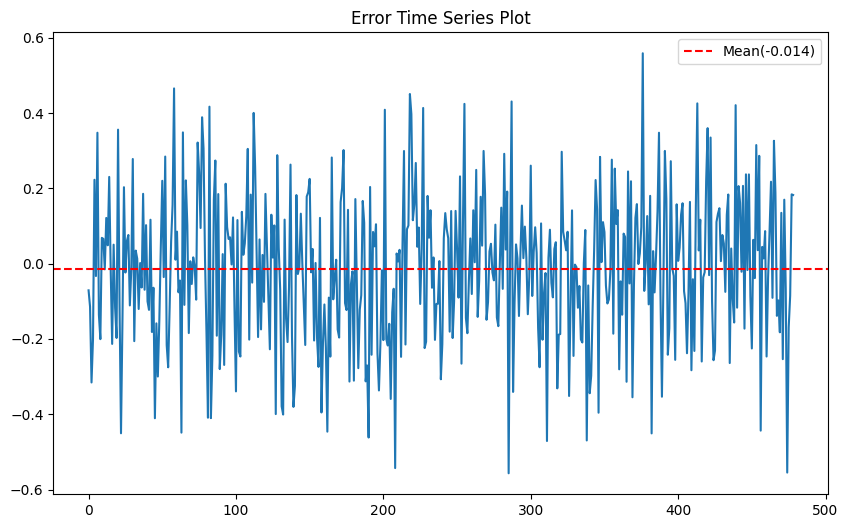

In [56]:
# Errors Time Series Plot to check for heteroskedastocity

error_mean = test_df['Error'].mean()

plt.figure(figsize=(10, 6))
plt.plot(test_df['Error'])
plt.axhline(
    error_mean, linestyle='--',  
    label=f'Mean({error_mean:.3f})', c='red'
)

plt.title('Error Time Series Plot')
plt.legend()
plt.show()

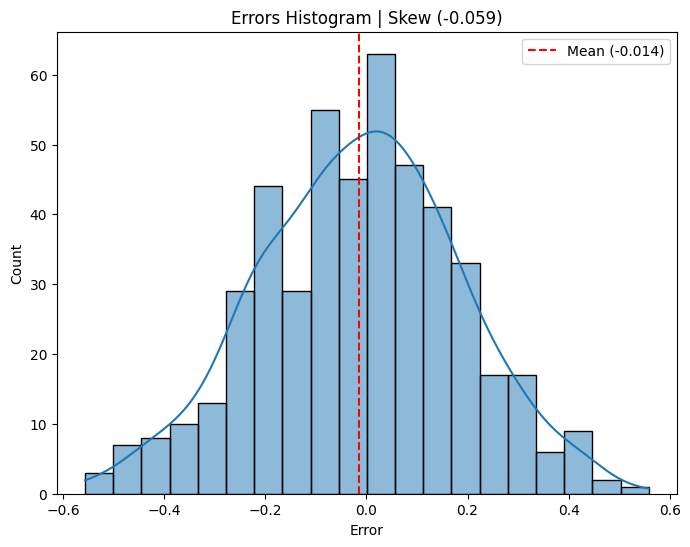

In [68]:
# Errors Normality

error_skew = test_df['Error'].skew()

plt.figure(figsize=(8, 6))
sns.histplot(
    data=test_df['Error'], kde=True, bins=20
)
plt.axvline(
    error_mean, linestyle='--',
    label=f'Mean ({error_mean:.3f})', c='red'
)

plt.title(f'Errors Histogram | Skew ({error_skew:.3f})')
plt.legend()
plt.show()

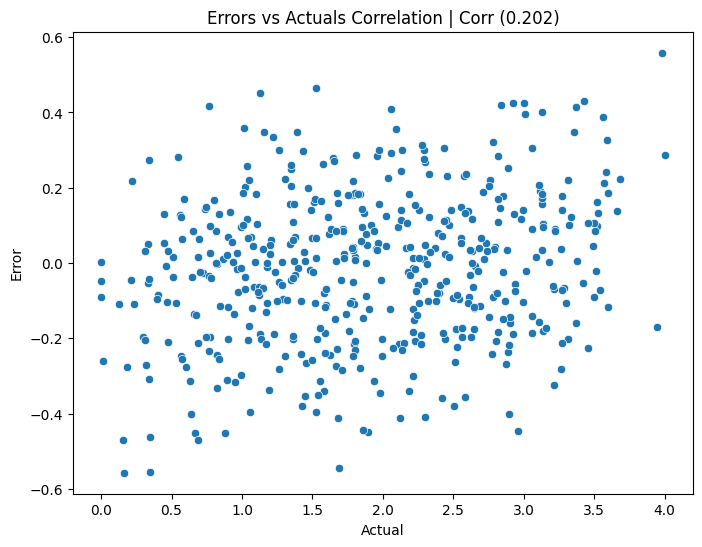

In [69]:
# Error vs Actual Correlation

error_corr = test_df[['Actual', 'Error']].corr()
error_corr = error_corr.loc['Actual', 'Error']

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=test_df,
    x='Actual',
    y='Error'
)

plt.title(f"Errors vs Actuals Correlation | Corr ({error_corr:.3f})")
plt.show()

**Interpretation**

The above plots show that the model pass the residuals diagnostics tests of a linear model:
- The residuals time series plot exhibits stationarity and homoskedasticity with a mean of ~0,
- The residuals histogram plot follows a normal distribution with a low skew of ~-0.06
- The relationship between the actual values and the errors is scattered and has a low skew of 0.2

This further solidifies that the model has captured as muvh signal as it can from the data.


## Features Importance

In the next section, I present the features importance (the coefficients of the independent variables) to see the level of influence each feature has on the GPA of a student.

In [80]:
coefficients = lin_reg['model'].coef_
features = lin_reg[:-1].get_feature_names_out()
features = [f.split('__')[-1] for f in features]

feature_df = pd.DataFrame({
    "Feature": features,
    "Coefficients": coefficients,
    "Abs Coefs": abs(coefficients)
})

feature_df = feature_df.sort_values(
    by='Abs Coefs', ascending=False
).reset_index(drop=True)

feature_df

,Feature,Coefficients,Abs Coefs
0,Absences,-2.893641,2.893641
1,StudyTimeWeekly,0.579881,0.579881
2,Tutoring,0.255560,0.255560
3,Sports,0.193565,0.193565
4,Extracurricular,0.188415,0.188415
5,ParentalSupport,0.153107,0.153107
6,Music,0.139421,0.139421
7,Age,-0.022180,0.022180
8,Female,0.015340,0.015340
9,Ethnicity_Caucasian,-0.007716,0.007716


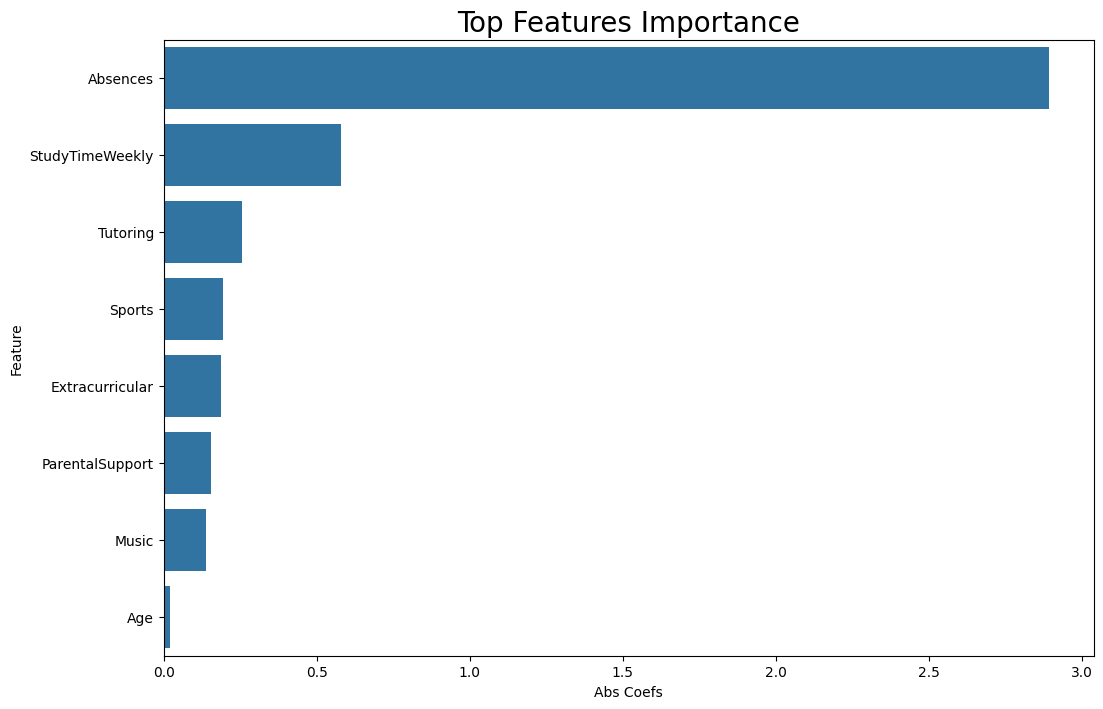

In [91]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=feature_df[:8],
    x='Abs Coefs',
    y='Feature',
    orient='h'
)

plt.title("Top Features Importance", fontsize=20)
plt.savefig('feature_importance.png', dpi=300)
plt.show()

In [94]:
def unscale_coef(x_scaled, x_min, x_max):
    return x_scaled / (x_max - x_min)

unscaled_absences = unscale_coef(-2.8936, 0, 29)
unscaled_study_time = unscale_coef(0.58, 0, 20)
print(f"Unscaled Absences Coefficient: {unscaled_absences}")
print(f"Unscaled Study Time Coefficient: {unscaled_study_time}")

Unscaled Absences Coefficient: -0.0997793103448276
Unscaled Study Time Coefficient: 0.028999999999999998


**Interpretation and Findings**

According to the above Features importance chart, Absences have the highest (negative) influence in determining a student's GPA. Interpreting the coefficient, which has been unscaled in the previous cell, a 1 unit increase in absence reduces GPA by 0.1 points (holding other features constant). This is consistent from what we've seen so far about the relationship between absences and GPA, from the correlation and the visualization. So a student with 10 absences in a session already has his potential GPA cut by 1 full point, such a student will have his work cut out for him.

Thw amount of hours a student studies per week, `StudyTimeWeekly`, has the next highest coefficient of 0.58 unscaled to ~0.03. That means for every 1 hour a studenr studies per week on average, they increase thei potential GPA by 0.03 points (holding other features constant). This is consistent with wide known deductions that the more a student studies, the higher their potential grades (GPA).

Tutoring, Music, Sports and Extracurricular activities have relatively high coefficients with respect to GPA. Being tutored increases a student's potential by ~0.26, participating in music, sports and extracurricular activities increases a student's potential GPA by 0.14, 0.19 and 0.19 respectively (holding other features constant and assuming independent additive effects). Participating in all four activities increases a student's potential GPA by approximately 0.78.

`ParentalSupport`, measured on a scale of 0 to 4, is another booster to a student's GPA. Receiving the highest level of Parental support, 4, leads to a potential 0.15 * 4 (0.6) increase in GPA.

The other features, such as age, gender and ethnicity, are negligible as they have coefficients close to 0 and don't hold much predictive power.


# Conclusion and Summary of Findings

This project set out to model the relationship between students' academic performance and their behaviour across severable variables such as Age, Ethnicity, Number od absent days in a session and the average number of hours studied weekly.

It followed an inquisitive data science path which includes loading the data, visualizing it, performing EDA and fitting a model. The model was then evaluated and it's residuals checked whether they follow the base linear regression modelling assumption.

The feature importances, effect of each feature on the target, was then plotted amd discussed. And it was found that absences severely impacts a student's GPA negatively, the average number of hours a student studies per week has a positive effect on their GPA. Participation in non-academic activities such as Music, Sports, Extracurricular and Tutoring also have positive effects on GPA, so does Parental support.

Features such as Gender, Age and Ethnicity had near zero coefficients, suggesting that these variables had negligible effects.

Overall, this project presented a numerical look into students' behaviours and their GPAs.

The challenges faced in this project were minimal as the data had already been cleaned.